# Gemini Vision API com Pydantic (Output Estruturado)

Este notebook demonstra como enviar uma imagem para o Gemini e converter a resposta JSON diretamente para um objeto **Pydantic**, garantindo validação de dados.

## Pré-requisitos
1. `GOOGLE_API_KEY` no arquivo `.env`.
2. Dependências: `google-generativeai`, `pydantic`, `Pillow`, `python-dotenv`.

In [62]:
import os
import typing
import json
import google.generativeai as genai
from dotenv import load_dotenv
from PIL import Image
import IPython.display
from pydantic import BaseModel, Field

# Carregar variáveis de ambiente
load_dotenv()
api_key = os.getenv("GOOGLE_API_KEY")

if not api_key or api_key == "your_api_key_here":
    print("Erro: Por favor, configure a GOOGLE_API_KEY no arquivo .env.")
else:
    genai.configure(api_key=api_key)
    print("SDK configurado.")

Erro: Por favor, configure a GOOGLE_API_KEY no arquivo .env.


## Definindo o Model com Pydantic

Usar `BaseModel` do Pydantic oferece validação automática e melhor suporte a IDEs.

In [63]:
class AnaliseImagem(BaseModel):
    objeto_principal: str = Field(description="O objeto mais proeminente na imagem")
    cor_predominante: str = Field(description="A cor principal visível")
    e_comida: bool = Field(description="Se a imagem contém algo comestível")
    estimativa_calorias: typing.Optional[int] = Field(None, description="Calorias estimadas se for comida")
    detalhes: str = Field(description="Descrição detalhada da cena")
    tags: list[str] = Field(description="Lista de palavras-chave sobre a imagem")

## Carregar Imagem

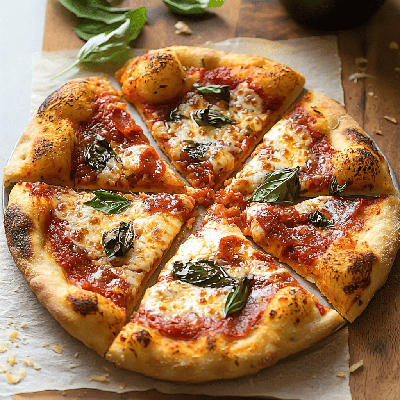

In [64]:
image_path = os.path.join('imagens', 'pizza.png') 
img = Image.open(image_path)
IPython.display.display(img.resize((400, 400)))

## Executar Request e Converter para Objeto Pydantic

In [ ]:
model = genai.GenerativeModel('gemini-2.5-flash')

print("Analisando imagem...")

response = model.generate_content(
    ["Analise esta imagem e retorne os dados conforme o esquema.", img],
    generation_config=genai.GenerationConfig(
        response_mime_type="application/json",
        response_schema=AnaliseImagem
    )
)

# 1. Converter string JSON para dict
dados_dict = json.loads(response.text)

# 2. Converter dict para objeto Pydantic (Validação)
analise = AnaliseImagem(**dados_dict)

print("\n--- Objeto Pydantic Criado ---")
print(f"Sucesso! Tipo do objeto: {type(analise)}")
print(analise)

print(f"\nAcessando atributos diretamente:")
print(f"- Objeto: {analise.objeto_principal}")
print(f"- Tags: {', '.join(analise.tags)}")
